In [3]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q albumentations timm grad-cam torch-ema kaggle

import os, random, platform
import numpy as np
import torch, torchvision
import albumentations as A
import timm, cv2
from pytorch_grad_cam import GradCAM
from torch_ema import ExponentialMovingAverage

print(f"Python          {platform.python_version()}")
print(f"PyTorch         {torch.__version__}")
print(f"NumPy           {np.__version__}")
print(f"Albumentations  {A.__version__}")
print(f"timm            {timm.__version__}")
print(f"OpenCV          {cv2.__version__}")

assert torch.cuda.is_available(), "No GPU. Runtime > Change runtime type > T4 GPU"
props = torch.cuda.get_device_properties(0)
print(f"\nGPU   {torch.cuda.get_device_name(0)}")
print(f"VRAM  {props.total_memory / 1e9:.1f} GB")
print(f"CUDA  {torch.version.cuda}")

torch.backends.cudnn.benchmark    = True
torch.backends.cudnn.deterministic = False

GLOBAL_SEED = 42

def seed_everything(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything()

PROJECT_ROOT = "/content/drive/MyDrive/heritage_damage_assessment"
DIRS = {
    "weights" : f"{PROJECT_ROOT}/weights",
    "outputs" : f"{PROJECT_ROOT}/outputs",
    "data"    : f"{PROJECT_ROOT}/data",
    "gradcam" : f"{PROJECT_ROOT}/outputs/gradcam",
}
for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

import builtins
builtins.DIRS            = DIRS
builtins.GLOBAL_SEED     = GLOBAL_SEED
builtins.seed_everything = seed_everything

print(f"\nProject  {PROJECT_ROOT}")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 90.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Python          3.12.13
PyTorch         2.10.0+cu128
NumPy           2.0.2
Albumentations  2.0.8
timm            1.0.26
OpenCV          4.13.0

GPU   Tesla T4
VRAM  15.6 GB
CUDA  12.8

Project  /content/drive/MyDrive/heritage_damage_assessment


In [4]:
# CELL 2 — MASTER CONFIG

CONFIG = {
    # Paths
    "data_dir"    : f"{PROJECT_ROOT}/data",
    "weights_dir" : DIRS["weights"],
    "outputs_dir" : DIRS["outputs"],
    "gradcam_dir" : DIRS["gradcam"],

    # Data
    "class_names" : ["Undamaged", "Partial Damage", "Damaged"],
    "num_classes" : 3,
    "image_size"  : 224,
    "splits"      : {"train": 0.70, "val": 0.15, "test": 0.15},

    # DataLoader
    "batch_size"       : 32,
    "num_workers"      : 2,
    "pin_memory"       : True,

    # Model
    "model_name"       : "resnet50",
    "pretrained"       : True,
    "dropout"          : 0.4,

    # Two-stage training
    "stage1_epochs"    : 8,    # backbone frozen, head only
    "stage2_epochs"    : 42,   # gradual unfreeze + full fine-tune
    "total_epochs"     : 50,

    # Learning rates
    "lr_head"          : 1e-3,
    "lr_layer4"        : 2e-5,
    "lr_layer3"        : 1e-5,
    "lr_layer2"        : 5e-6,
    "lr_min"           : 1e-7,  # cosine annealing floor

    # Regularization
    "weight_decay"     : 1e-4,
    "label_smoothing"  : 0.1,
    "grad_clip"        : 1.0,

    # Augmentation
    "mixup_alpha"      : 0.4,   # mixup coefficient — big generalization boost
    "cutmix_alpha"     : 1.0,   # cutmix coefficient
    "mixup_prob"       : 0.5,   # probability of applying mixup or cutmix per batch

    # EMA — exponential moving average of weights
    # produces a smoother, better-generalizing model at zero training cost
    "ema_decay"        : 0.9998,

    # Scheduler
    "warmup_epochs"    : 3,     # linear LR warmup before cosine decay

    # Early stopping
    "patience"         : 10,    # stop if val F1 doesn't improve for N epochs

    # Hardware
    "device"           : "cuda",
    "use_amp"          : True,  # mixed precision — faster + less VRAM
    "seed"             : GLOBAL_SEED,
}

# Validate no conflicts
assert CONFIG["stage1_epochs"] + CONFIG["stage2_epochs"] == CONFIG["total_epochs"]
assert CONFIG["num_classes"] == len(CONFIG["class_names"])

import builtins
builtins.CONFIG = CONFIG

print("Config summary")
print(f"  Classes       {CONFIG['class_names']}")
print(f"  Image size    {CONFIG['image_size']}x{CONFIG['image_size']}")
print(f"  Batch size    {CONFIG['batch_size']}")
print(f"  Total epochs  {CONFIG['total_epochs']}  (stage1={CONFIG['stage1_epochs']}, stage2={CONFIG['stage2_epochs']})")
print(f"  AMP           {CONFIG['use_amp']}")
print(f"  EMA decay     {CONFIG['ema_decay']}")
print(f"  Mixup alpha   {CONFIG['mixup_alpha']}")
print(f"  CutMix alpha  {CONFIG['cutmix_alpha']}")
print(f"  Label smooth  {CONFIG['label_smoothing']}")
print(f"  Warmup        {CONFIG['warmup_epochs']} epochs")
print(f"  Patience      {CONFIG['patience']} epochs")
print(f"  Weights dir   {CONFIG['weights_dir']}")
print("\nCell 2 complete ✓")

Config summary
  Classes       ['Undamaged', 'Partial Damage', 'Damaged']
  Image size    224x224
  Batch size    32
  Total epochs  50  (stage1=8, stage2=42)
  AMP           True
  EMA decay     0.9998
  Mixup alpha   0.4
  CutMix alpha  1.0
  Label smooth  0.1
  Warmup        3 epochs
  Patience      10 epochs
  Weights dir   /content/drive/MyDrive/heritage_damage_assessment/weights

Cell 2 complete ✓


In [5]:
# CELL 3 — KAGGLE SETUP & DATASET DOWNLOAD

import os, json
from pathlib import Path

KAGGLE_USERNAME = "shresthaadi"   # your kaggle profile name
KAGGLE_KEY      = "KGAT_1f98c660851dc644dce74df1978f1c19"    # the key you copied

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print(f"Kaggle configured for user: {KAGGLE_USERNAME}\n")

RAW = "/content/raw"
os.makedirs(RAW, exist_ok=True)

DATASETS = [
    ("arnavr10880/concrete-crack-images-for-classification", "concrete_cracks"),
    ("anasmohammedtahir/aider",                              "aider"),
    ("doken/quakeset",                                       "quakeset"),
]

for dataset_id, folder in DATASETS:
    dest = Path(RAW) / folder
    if dest.exists() and sum(1 for _ in dest.rglob("*") if _.is_file()) > 10:
        n = sum(1 for _ in dest.rglob("*") if _.is_file())
        print(f"  SKIP  {folder:<30} ({n} files)")
        continue
    dest.mkdir(parents=True, exist_ok=True)
    print(f"  GET   {dataset_id} ...", end=" ", flush=True)
    ret = os.system(f"kaggle datasets download -d {dataset_id} -p {dest} --unzip -q 2>/dev/null")
    n   = sum(1 for _ in dest.rglob("*") if _.is_file())
    print(f"OK ({n} files)" if ret == 0 else "FAILED — wrong dataset ID")

print("\nFolder structures:")
for _, folder in DATASETS:
    p = Path(RAW) / folder
    if p.exists():
        print(f"\n{folder}/")
        for item in sorted(p.iterdir()):
            if item.is_dir():
                print(f"  {item.name}/")
                for c in sorted(item.iterdir())[:5]:
                    n = sum(1 for _ in c.rglob("*") if _.is_file()) if c.is_dir() else 1
                    print(f"    {c.name}  ({n} files)")

import builtins
builtins.RAW = RAW
print("\nCell 3 complete ✓")

Kaggle configured for user: shresthaadi

  GET   arnavr10880/concrete-crack-images-for-classification ... OK (40000 files)
  GET   anasmohammedtahir/aider ... FAILED — wrong dataset ID
  GET   doken/quakeset ... FAILED — wrong dataset ID

Folder structures:

concrete_cracks/
  Negative/
    00001.jpg  (1 files)
    00002.jpg  (1 files)
    00003.jpg  (1 files)
    00004.jpg  (1 files)
    00005.jpg  (1 files)
  Positive/
    00001.jpg  (1 files)
    00002.jpg  (1 files)
    00003.jpg  (1 files)
    00004.jpg  (1 files)
    00005.jpg  (1 files)

aider/

quakeset/

Cell 3 complete ✓


In [6]:
# CELL 3B — FIND CORRECT DATASET IDs

print("=== Building / structural damage ===")
!kaggle datasets list -s "building damage" --sort-by votes --csv 2>/dev/null | head -15

print("\n=== Earthquake damage ===")
!kaggle datasets list -s "earthquake damage" --sort-by votes --csv 2>/dev/null | head -15

print("\n=== Crack detection ===")
!kaggle datasets list -s "crack detection classification" --sort-by votes --csv 2>/dev/null | head -10

print("\n=== Heritage monument ===")
!kaggle datasets list -s "heritage monument" --sort-by votes --csv 2>/dev/null | head -10

=== Building / structural damage ===
ref,title,size,lastUpdated,downloadCount,voteCount,usabilityRating
anmolkumar/health-insurance-cross-sell-prediction,Health Insurance Cross Sell Prediction 🏠 🏥,6782114,2020-09-11 18:39:31.787000,49863,786,1
utsavdey1410/food-nutrition-dataset,Food Nutrition Dataset,710871,2024-06-29 19:42:01.947000,24089,278,1
patricklford/water-and-air-quality,Water Quality -  Every Drop Matters.,286963,2024-01-13 22:29:17.307000,6421,121,1
mirzahasnine/loan-data-set,Loan Data Set,11171,2023-03-12 05:02:43.500000,10618,95,0.9411765
alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023,All the Earthquakes Dataset : from 1990-2023,121537542,2023-08-07 07:43:32.610000,10273,94,1
zusmani/home-demolitions-in-palestine-20042021,Forced Home Demolitions in Palestine (2004-2021),3151,2021-05-24 20:28:19.813000,968,84,1
desalegngeb/conversion-predictors-of-cis-to-multiple-sclerosis,Multiple Sclerosis Disease,3097,2023-05-18 09:41:09.267000,6426,82,1
arashnic/imbal

In [7]:
# CELL 3C — DOWNLOAD ADDITIONAL DATASETS

from pathlib import Path
import os

ADDITIONAL = [
    ("arunrk7/surface-crack-detection",           "surface_cracks"),
    ("varpit94/disaster-images-dataset",           "disaster"),
    ("oluwaseunad/concrete-and-pavement-crack-images", "pavement_cracks"),
]

for dataset_id, folder in ADDITIONAL:
    dest = Path(RAW) / folder
    if dest.exists() and sum(1 for _ in dest.rglob("*") if _.is_file()) > 10:
        n = sum(1 for _ in dest.rglob("*") if _.is_file())
        print(f"  SKIP  {folder:<35} ({n} files)")
        continue
    dest.mkdir(parents=True, exist_ok=True)
    print(f"  GET   {dataset_id} ...", end=" ", flush=True)
    ret = os.system(f"kaggle datasets download -d {dataset_id} -p {dest} --unzip -q 2>/dev/null")
    n   = sum(1 for _ in dest.rglob("*") if _.is_file())
    print(f"OK ({n} files)" if ret == 0 else "FAILED")

# Print full folder structures so we know exact subfolder names
print("\nFolder structures:")
ALL_FOLDERS = ["concrete_cracks"] + [f[1] for f in ADDITIONAL]
for folder in ALL_FOLDERS:
    p = Path(RAW) / folder
    if not p.exists():
        continue
    print(f"\n{folder}/")
    for item in sorted(p.rglob("*")):
        depth = len(item.relative_to(p).parts)
        if depth > 3:
            continue
        if item.is_dir():
            n = sum(1 for _ in item.rglob("*") if _.is_file())
            indent = "  " * depth
            print(f"{indent}{item.name}/  ({n} files)")

  GET   arunrk7/surface-crack-detection ... OK (40000 files)
  GET   varpit94/disaster-images-dataset ... OK (13557 files)
  GET   oluwaseunad/concrete-and-pavement-crack-images ... OK (30000 files)

Folder structures:

concrete_cracks/
  Negative/  (20000 files)
  Positive/  (20000 files)

surface_cracks/
  Negative/  (20000 files)
  Positive/  (20000 files)

disaster/
  Comprehensive Disaster Dataset(CDD)/  (13557 files)
    Damaged_Infrastructure/  (1454 files)
      Earthquake/  (36 files)
      Infrastructure/  (1418 files)
    Fire_Disaster/  (933 files)
      Urban_Fire/  (419 files)
      Wild_Fire/  (514 files)
    Human_Damage/  (241 files)
    Land_Disaster/  (657 files)
      Drought/  (201 files)
      Land_Slide/  (456 files)
    Non_Damage/  (9237 files)
      Non_Damage_Buildings_Street/  (4572 files)
      Non_Damage_Wildlife_Forest/  (2271 files)
      human/  (120 files)
      sea/  (2274 files)
    Water_Disaster/  (1035 files)

pavement_cracks/
  Negative/  (15000 

In [11]:
# Clear existing organized data
import shutil
shutil.rmtree(DATA_DIR)
print("Cleared.")

Cleared.


In [12]:
# Re-run Cell 4 with pavement cracks removed from Damaged
import shutil, random
from pathlib import Path

seed_everything()

DATA_DIR  = CONFIG["data_dir"]
SPLITS    = CONFIG["splits"]
IMG_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "val", "test"]:
    for cls in CONFIG["class_names"]:
        Path(f"{DATA_DIR}/{split}/{cls}").mkdir(parents=True, exist_ok=True)

SOURCES = [
    (f"{RAW}/disaster/Comprehensive Disaster Dataset(CDD)/Non_Damage/Non_Damage_Buildings_Street",
     "Undamaged", None),
    (f"{RAW}/concrete_cracks/Negative",  "Undamaged",      1500),
    (f"{RAW}/surface_cracks/Positive",   "Partial Damage", 4000),
    (f"{RAW}/concrete_cracks/Positive",  "Partial Damage", 4000),
    (f"{RAW}/disaster/Comprehensive Disaster Dataset(CDD)/Damaged_Infrastructure",
     "Damaged", None),
]

def collect_images(folder, cap):
    imgs = [p for p in Path(folder).rglob("*")
            if p.is_file() and p.suffix.lower() in IMG_EXTS]
    if cap and len(imgs) > cap:
        imgs = random.sample(imgs, cap)
    return imgs

def copy_split(images, cls, src_idx):
    random.shuffle(images)
    n       = len(images)
    n_train = int(n * SPLITS["train"])
    n_val   = int(n * SPLITS["val"])
    buckets = {
        "train": images[:n_train],
        "val"  : images[n_train:n_train + n_val],
        "test" : images[n_train + n_val:],
    }
    counts = {}
    for split, imgs in buckets.items():
        counts[split] = 0
        for img in imgs:
            dest = Path(DATA_DIR) / split / cls / f"s{src_idx}_{img.name}"
            if not dest.exists():
                shutil.copy2(img, dest)
            counts[split] += 1
    return counts

print(f"{'Source':<45} {'Class':<15} {'Total':>6} {'Train':>6} {'Val':>5} {'Test':>5}")
print("─" * 85)

totals = {cls: {"train": 0, "val": 0, "test": 0} for cls in CONFIG["class_names"]}

for idx, (src, cls, cap) in enumerate(SOURCES):
    if not Path(src).exists():
        print(f"  MISSING  {src}")
        continue
    images = collect_images(src, cap)
    counts = copy_split(images, cls, idx)
    for split in counts:
        totals[cls][split] += counts[split]
    total = sum(counts.values())
    print(f"  {Path(src).name:<43} {cls:<15} {total:>6} {counts['train']:>6} {counts['val']:>5} {counts['test']:>5}")

print("\nFinal distribution:")
print(f"  {'Class':<15} {'Train':>7} {'Val':>6} {'Test':>6} {'Total':>7}")
print("  " + "─" * 42)
grand = 0
for cls in CONFIG["class_names"]:
    t     = totals[cls]
    total = sum(t.values())
    grand += total
    print(f"  {cls:<15} {t['train']:>7} {t['val']:>6} {t['test']:>6} {total:>7}")
print(f"  {'TOTAL':<15} "
      f"{sum(totals[c]['train'] for c in CONFIG['class_names']):>7} "
      f"{sum(totals[c]['val']   for c in CONFIG['class_names']):>6} "
      f"{sum(totals[c]['test']  for c in CONFIG['class_names']):>6} "
      f"{grand:>7}")

import builtins
builtins.DATA_DIR = DATA_DIR
print("\nCell 4 complete ✓")

Source                                        Class            Total  Train   Val  Test
─────────────────────────────────────────────────────────────────────────────────────
  Non_Damage_Buildings_Street                 Undamaged         4572   3200   685   687
  Negative                                    Undamaged         1500   1050   225   225
  Positive                                    Partial Damage    4000   2800   600   600
  Positive                                    Partial Damage    4000   2800   600   600
  Damaged_Infrastructure                      Damaged           1454   1017   218   219

Final distribution:
  Class             Train    Val   Test   Total
  ──────────────────────────────────────────
  Undamaged          4250    910    912    6072
  Partial Damage     5600   1200   1200    8000
  Damaged            1017    218    219    1454
  TOTAL             10867   2328   2331   15526

Cell 4 complete ✓


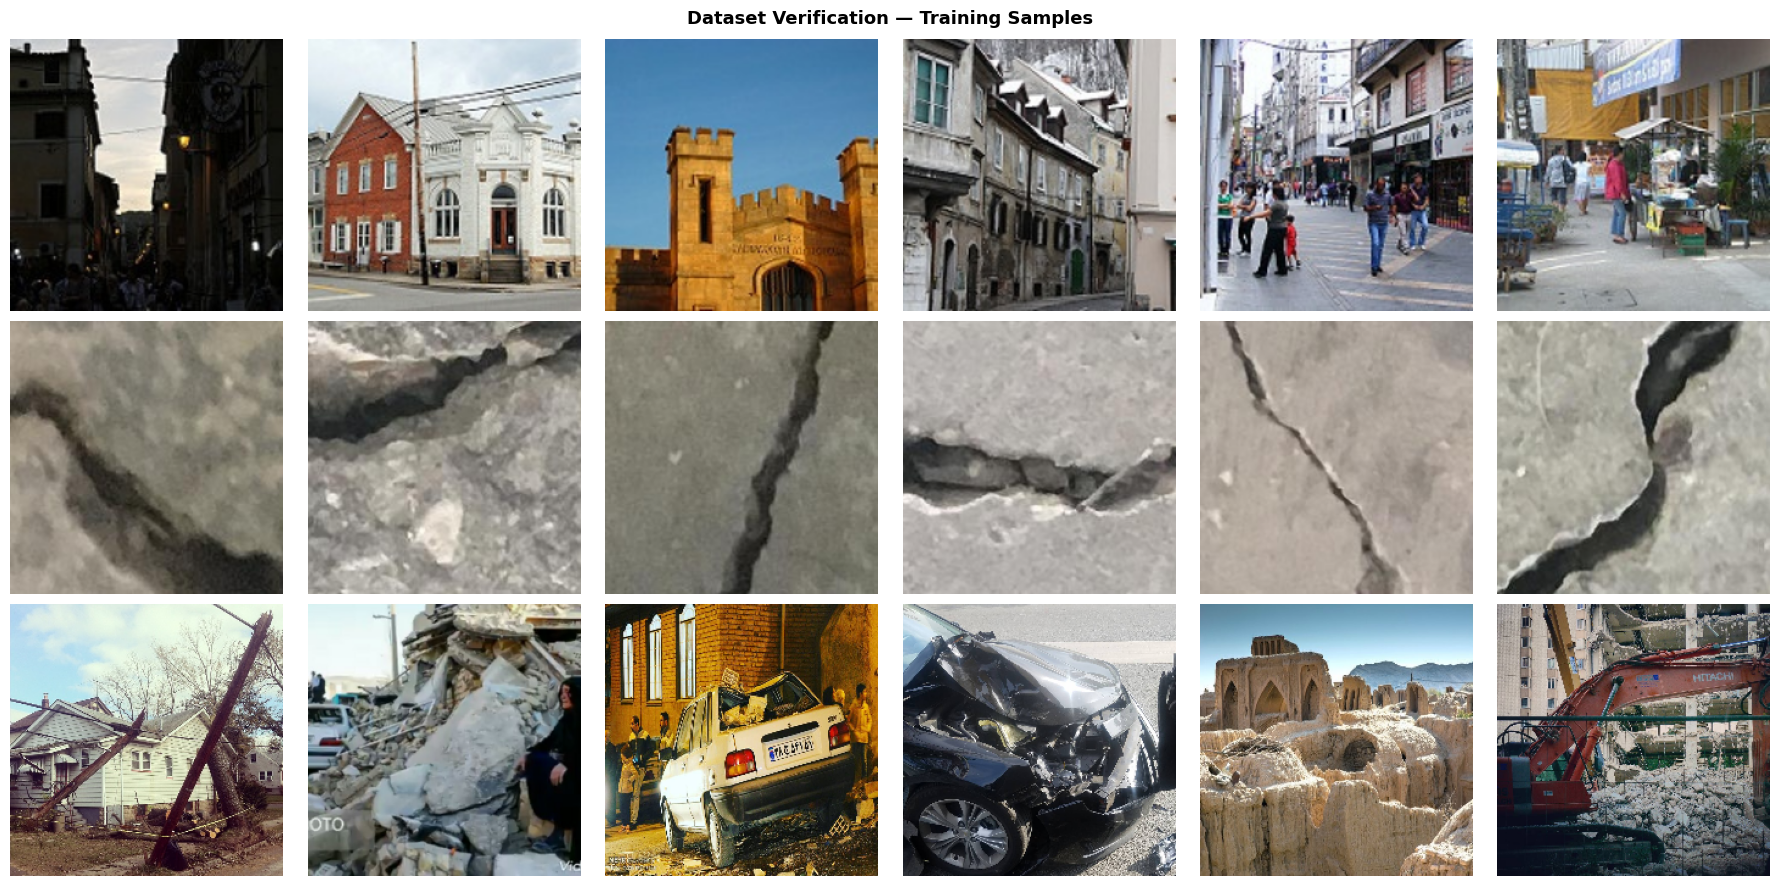

In [13]:
import cv2, random, matplotlib.pyplot as plt
from pathlib import Path

seed_everything()

fig, axes = plt.subplots(len(CONFIG["class_names"]), 6, figsize=(18, 9))
fig.suptitle("Dataset Verification — Training Samples", fontsize=13, fontweight="bold")

for row, cls in enumerate(CONFIG["class_names"]):
    cls_dir = Path(DATA_DIR) / "train" / cls
    samples = random.sample(list(cls_dir.iterdir()), 6)
    for col, img_path in enumerate(samples):
        ax  = axes[row, col]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(cv2.resize(img, (224, 224)))
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{DIRS['outputs']}/dataset_verification.png", dpi=130, bbox_inches="tight")
plt.show()

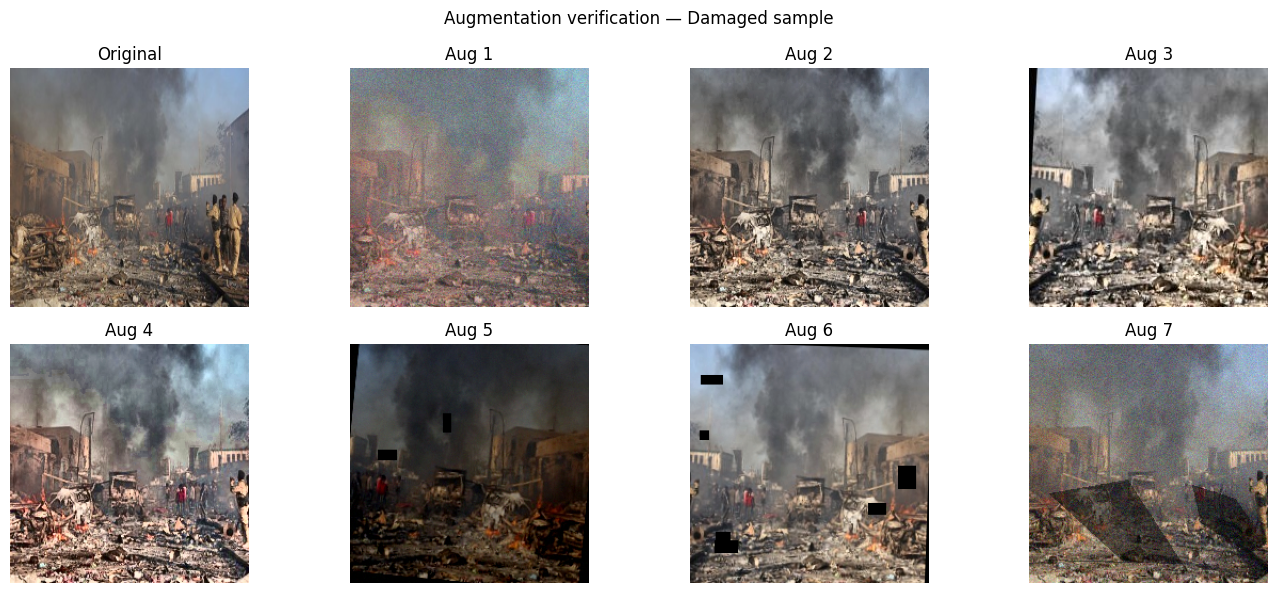

train_tfm  ready
val_tfm    ready

Cell 5 complete ✓


In [14]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

sz   = CONFIG["image_size"]
mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

train_tfm = A.Compose([
    A.RandomResizedCrop(size=(sz, sz), scale=(0.65, 1.0), ratio=(0.75, 1.33)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Rotate(limit=20, p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.3),
    A.CLAHE(clip_limit=3.0, p=0.35),
    A.RandomShadow(p=0.2),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.25),
    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),
        A.GaussianBlur(blur_limit=5, p=1.0),
    ], p=0.2),
    A.ImageCompression(quality_range=(75, 95), p=0.2),
    A.CoarseDropout(num_holes_range=(1, 6),
                    hole_height_range=(8, sz // 10),
                    hole_width_range=(8, sz // 10),
                    fill=0, p=0.25),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

val_tfm = A.Compose([
    A.Resize(height=sz, width=sz),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

import builtins
builtins.train_tfm = train_tfm
builtins.val_tfm   = val_tfm

def denormalize(tensor):
    img = tensor.permute(1, 2, 0).numpy().copy()
    return np.clip(img * np.array(std) + np.array(mean), 0, 1)

sample_path = next(Path(f"{DATA_DIR}/train/Damaged").iterdir())
sample_img  = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Augmentation verification — Damaged sample")
axes[0, 0].imshow(cv2.resize(sample_img, (sz, sz)))
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")
for i, ax in enumerate(axes.flat[1:]):
    ax.imshow(denormalize(train_tfm(image=sample_img)["image"]))
    ax.set_title(f"Aug {i+1}")
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{DIRS['outputs']}/augmentation_preview.png", dpi=120)
plt.show()

print("train_tfm  ready")
print("val_tfm    ready")
print("\nCell 5 complete ✓")

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import cv2
from pathlib import Path

class HeritageDamageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform  = transform
        self.class_names = CONFIG["class_names"]
        self.class_to_idx = {c: i for i, c in enumerate(self.class_names)}
        self.samples = [
            (str(p), self.class_to_idx[p.parent.name])
            for cls in self.class_names
            for p in (Path(root) / cls).iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label


def get_dataloaders(cfg):
    train_ds = HeritageDamageDataset(f"{DATA_DIR}/train", transform=train_tfm)
    val_ds   = HeritageDamageDataset(f"{DATA_DIR}/val",   transform=val_tfm)
    test_ds  = HeritageDamageDataset(f"{DATA_DIR}/test",  transform=val_tfm)

    class_counts = torch.zeros(cfg["num_classes"])
    for _, label in train_ds.samples:
        class_counts[label] += 1

    class_weights  = 1.0 / (class_counts + 1e-6)
    sample_weights = [class_weights[label] for _, label in train_ds.samples]
    sampler = WeightedRandomSampler(
        weights     = sample_weights,
        num_samples = len(sample_weights),
        replacement = True,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size         = cfg["batch_size"],
        sampler            = sampler,
        num_workers        = cfg["num_workers"],
        pin_memory         = cfg["pin_memory"],
        persistent_workers = True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size         = cfg["batch_size"] * 2,
        shuffle            = False,
        num_workers        = cfg["num_workers"],
        pin_memory         = cfg["pin_memory"],
        persistent_workers = True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size         = cfg["batch_size"] * 2,
        shuffle            = False,
        num_workers        = cfg["num_workers"],
        pin_memory         = cfg["pin_memory"],
        persistent_workers = True,
    )

    return train_loader, val_loader, test_loader, class_counts


train_loader, val_loader, test_loader, class_counts = get_dataloaders(CONFIG)

print("Dataset sizes:")
for i, cls in enumerate(CONFIG["class_names"]):
    count  = int(class_counts[i])
    weight = 1.0 / count
    print(f"  {cls:<15}  {count:>5} images   sample weight {weight:.6f}")

print(f"\nDataLoader batches:")
print(f"  train  {len(train_loader)} batches")
print(f"  val    {len(val_loader)} batches")
print(f"  test   {len(test_loader)} batches")

batch_imgs, batch_labels = next(iter(train_loader))
print(f"\nBatch shape  {tuple(batch_imgs.shape)}")
print(f"Label sample {batch_labels[:8].tolist()}")
print(f"dtype        {batch_imgs.dtype}")
print(f"value range  [{batch_imgs.min():.2f}, {batch_imgs.max():.2f}]")

import builtins
builtins.train_loader = train_loader
builtins.val_loader   = val_loader
builtins.test_loader  = test_loader
builtins.class_counts = class_counts

print("\nCell 6 complete ✓")

Dataset sizes:
  Undamaged         4250 images   sample weight 0.000235
  Partial Damage    5600 images   sample weight 0.000179
  Damaged           1017 images   sample weight 0.000983

DataLoader batches:
  train  340 batches
  val    37 batches
  test   37 batches

Batch shape  (32, 3, 224, 224)
Label sample [0, 0, 0, 1, 1, 2, 2, 0]
dtype        torch.float32
value range  [-2.12, 2.64]

Cell 6 complete ✓


In [16]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch_ema import ExponentialMovingAverage

def build_model(cfg):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(p=cfg["dropout"]),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.3),
        nn.Linear(512, cfg["num_classes"]),
    )
    return model


def unfreeze_layers(model, layer_names):
    for name, child in model.named_children():
        if name in layer_names:
            for param in child.parameters():
                param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(
            logits, targets,
            label_smoothing=self.label_smoothing,
            reduction="none"
        )
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


def get_stage1_optimizer(model, cfg):
    return torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr           = cfg["lr_head"],
        weight_decay = cfg["weight_decay"],
    )


def get_stage2_optimizer(model, cfg):
    return torch.optim.AdamW([
        {"params": model.layer2.parameters(), "lr": cfg["lr_layer2"]},
        {"params": model.layer3.parameters(), "lr": cfg["lr_layer3"]},
        {"params": model.layer4.parameters(), "lr": cfg["lr_layer4"]},
        {"params": model.fc.parameters(),     "lr": cfg["lr_head"] * 0.1},
    ], weight_decay=cfg["weight_decay"])


def get_scheduler(optimizer, cfg, num_epochs):
    def lr_lambda(epoch):
        if epoch < cfg["warmup_epochs"]:
            return (epoch + 1) / cfg["warmup_epochs"]
        progress = (epoch - cfg["warmup_epochs"]) / max(num_epochs - cfg["warmup_epochs"], 1)
        return 0.5 * (1.0 + torch.cos(torch.tensor(3.14159 * progress)).item())
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


model     = build_model(CONFIG).to(CONFIG["device"])
criterion = FocalLoss(gamma=2.0, label_smoothing=CONFIG["label_smoothing"])
ema       = ExponentialMovingAverage(model.parameters(), decay=CONFIG["ema_decay"])

print("Model   ResNet50 (IMAGENET1K_V2)")
print(f"Head    {model.fc}")
print(f"\nStage 1 — frozen backbone, head only:")
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"  Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print(f"\nLoss    FocalLoss(gamma=2.0, label_smoothing={CONFIG['label_smoothing']})")
print(f"EMA     decay={CONFIG['ema_decay']}")

import builtins
builtins.model     = model
builtins.criterion = criterion
builtins.ema       = ema
builtins.build_model      = build_model
builtins.unfreeze_layers  = unfreeze_layers
builtins.get_stage1_optimizer = get_stage1_optimizer
builtins.get_stage2_optimizer = get_stage2_optimizer
builtins.get_scheduler        = get_scheduler

print("\nCell 7 complete ✓")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 90.1MB/s]


Model   ResNet50 (IMAGENET1K_V2)
Head    Sequential(
  (0): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (1): Dropout(p=0.4, inplace=False)
  (2): Linear(in_features=2048, out_features=512, bias=True)
  (3): ReLU(inplace=True)
  (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=512, out_features=3, bias=True)
)

Stage 1 — frozen backbone, head only:
  Trainable params: 1,055,747 / 24,563,779 (4.3%)

Loss    FocalLoss(gamma=2.0, label_smoothing=0.1)
EMA     decay=0.9998

Cell 7 complete ✓


In [17]:
import time, json, shutil
import numpy as np
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import f1_score
from pathlib import Path

def apply_mixup(images, labels, alpha, device):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(images.size(0)).to(device)
    mixed = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam

def apply_cutmix(images, labels, alpha, device):
    lam             = np.random.beta(alpha, alpha)
    idx             = torch.randperm(images.size(0)).to(device)
    _, _, H, W      = images.shape
    cut_h, cut_w    = int(H * np.sqrt(1 - lam)), int(W * np.sqrt(1 - lam))
    cx, cy          = np.random.randint(H), np.random.randint(W)
    x1, x2          = max(0, cx - cut_h // 2), min(H, cx + cut_h // 2)
    y1, y2          = max(0, cy - cut_w // 2), min(W, cy + cut_w // 2)
    mixed           = images.clone()
    mixed[:, :, x1:x2, y1:y2] = images[idx, :, x1:x2, y1:y2]
    lam             = 1 - (x2 - x1) * (y2 - y1) / (H * W)
    return mixed, labels, labels[idx], lam

def mixed_loss(criterion, outputs, la, lb, lam):
    return lam * criterion(outputs, la) + (1 - lam) * criterion(outputs, lb)

def train_epoch(model, loader, criterion, optimizer, scaler, ema, cfg):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    device = cfg["device"]

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        use_mix = np.random.random() < cfg["mixup_prob"]
        if use_mix:
            fn     = apply_mixup if np.random.random() < 0.5 else apply_cutmix
            images, la, lb, lam = fn(images, labels, cfg["mixup_alpha"], device)

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            outputs = model(images)
            loss    = mixed_loss(criterion, outputs, la, lb, lam) if use_mix else criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
        scaler.step(optimizer)
        scaler.update()
        ema.update()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == (la if use_mix else labels)).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, cfg):
    device = cfg["device"]

    def _loop():
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        return running_loss / total, correct / total, all_preds, all_labels

    with ema.average_parameters():
        return _loop()

def save_checkpoint(state, filename):
    local = f"/content/{filename}"
    drive = f"{DIRS['weights']}/{filename}"
    torch.save(state, local)
    shutil.copy2(local, drive)

def load_checkpoint(filename):
    path = Path(f"{DIRS['weights']}/{filename}")
    if path.exists():
        return torch.load(path, map_location=CONFIG["device"])
    return None

def save_history(history):
    path = f"{DIRS['outputs']}/training_history.json"
    with open(path, "w") as f:
        json.dump(history, f, indent=2)

import builtins
builtins.train_epoch      = train_epoch
builtins.evaluate         = evaluate
builtins.save_checkpoint  = save_checkpoint
builtins.load_checkpoint  = load_checkpoint
builtins.save_history     = save_history

print("Cell 8 complete ✓")

Cell 8 complete ✓


In [18]:
seed_everything()
scaler  = GradScaler()
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": [], "lr": []}
best_f1      = 0.0
start_epoch  = 0
current_stage = 1
patience_counter = 0

# Resume from checkpoint if exists
ckpt = load_checkpoint("checkpoint_latest.pth")
if ckpt:
    model.load_state_dict(ckpt["model_state"])
    ema.load_state_dict(ckpt["ema_state"])
    history       = ckpt["history"]
    best_f1       = ckpt["best_f1"]
    start_epoch   = ckpt["epoch"] + 1
    current_stage = ckpt["stage"]
    patience_counter = ckpt.get("patience_counter", 0)
    print(f"Resumed from epoch {start_epoch} | best F1 {best_f1:.4f} | stage {current_stage}")
else:
    print("Starting fresh training")

# Build optimizers and schedulers for both stages
optimizer_s1 = get_stage1_optimizer(model, CONFIG)
scheduler_s1 = get_scheduler(optimizer_s1, CONFIG, CONFIG["stage1_epochs"])

# Restore optimizer state if resuming mid-stage
if ckpt and current_stage == 1 and "optimizer_state" in ckpt:
    optimizer_s1.load_state_dict(ckpt["optimizer_state"])
    scheduler_s1.load_state_dict(ckpt["scheduler_state"])

print(f"\nStage 1: epochs 1–{CONFIG['stage1_epochs']} (head only)")
print(f"Stage 2: epochs {CONFIG['stage1_epochs']+1}–{CONFIG['total_epochs']} (layer2+3+4+head)")
print(f"\n{'Ep':>3} {'Stage':>5} {'TrLoss':>8} {'TrAcc':>7} {'VlLoss':>8} {'VlAcc':>7} {'VlF1':>7} {'LR':>10} {'Time':>6} {'':>8}")
print("─" * 95)

for epoch in range(start_epoch, CONFIG["total_epochs"]):

    # Stage transition
    if epoch == CONFIG["stage1_epochs"] and current_stage == 1:
        current_stage = 2
        print(f"\nTransitioning to Stage 2 — unfreezing layer2, layer3, layer4")
        unfreeze_layers(model, ["layer2", "layer3", "layer4"])
        optimizer_s2 = get_stage2_optimizer(model, CONFIG)
        scheduler_s2 = get_scheduler(optimizer_s2, CONFIG, CONFIG["stage2_epochs"])
        if ckpt and "optimizer_state" in ckpt and ckpt["stage"] == 2:
            optimizer_s2.load_state_dict(ckpt["optimizer_state"])
            scheduler_s2.load_state_dict(ckpt["scheduler_state"])
        print()

    optimizer = optimizer_s1 if current_stage == 1 else optimizer_s2
    scheduler = scheduler_s1 if current_stage == 1 else scheduler_s2

    t0 = time.time()
    tr_loss, tr_acc                    = train_epoch(model, train_loader, criterion, optimizer, scaler, ema, CONFIG)
    vl_loss, vl_acc, vl_preds, vl_labels = evaluate(model, val_loader, criterion, CONFIG)
    scheduler.step()

    val_f1     = f1_score(vl_labels, vl_preds, average="weighted")
    current_lr = optimizer.param_groups[0]["lr"]
    elapsed    = time.time() - t0

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    improved = val_f1 > best_f1
    if improved:
        best_f1 = val_f1
        patience_counter = 0
        save_checkpoint({
            "epoch"           : epoch,
            "stage"           : current_stage,
            "model_state"     : model.state_dict(),
            "ema_state"       : ema.state_dict(),
            "optimizer_state" : optimizer.state_dict(),
            "scheduler_state" : scheduler.state_dict(),
            "best_f1"         : best_f1,
            "history"         : history,
            "patience_counter": patience_counter,
        }, "resnet50_best.pth")
    else:
        patience_counter += 1

    save_checkpoint({
        "epoch"           : epoch,
        "stage"           : current_stage,
        "model_state"     : model.state_dict(),
        "ema_state"       : ema.state_dict(),
        "optimizer_state" : optimizer.state_dict(),
        "scheduler_state" : scheduler.state_dict(),
        "best_f1"         : best_f1,
        "history"         : history,
        "patience_counter": patience_counter,
    }, "checkpoint_latest.pth")

    save_history(history)

    flag = "✓ best" if improved else f"no gain {patience_counter}/{CONFIG['patience']}"
    print(
        f"{epoch+1:>3} {'S'+str(current_stage):>5}"
        f"  {tr_loss:>8.4f}  {tr_acc:>7.4f}"
        f"  {vl_loss:>8.4f}  {vl_acc:>7.4f}  {val_f1:>7.4f}"
        f"  {current_lr:>10.2e}  {elapsed:>5.0f}s  {flag}"
    )

    if patience_counter >= CONFIG["patience"]:
        print(f"\nEarly stopping at epoch {epoch+1}. Best val F1: {best_f1:.4f}")
        break

print(f"\nTraining complete. Best val F1: {best_f1:.4f}")
print(f"Best model  → {DIRS['weights']}/resnet50_best.pth")
print(f"History     → {DIRS['outputs']}/training_history.json")

/tmp/ipykernel_1208/1253851500.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler()


Starting fresh training

Stage 1: epochs 1–8 (head only)
Stage 2: epochs 9–50 (layer2+3+4+head)

 Ep Stage   TrLoss   TrAcc   VlLoss   VlAcc    VlF1         LR   Time         
───────────────────────────────────────────────────────────────────────────────────────────────


/tmp/ipykernel_1208/3881159524.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1208/3881159524.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  1    S1    0.2198   0.8080    0.0463   0.9854   0.9854    6.67e-04    183s  ✓ best


/tmp/ipykernel_1208/3881159524.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1208/3881159524.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

 27    S2    0.0954   0.8787    0.0429   0.9987   0.9987    3.20e-06    168s  no gain 8/10


/tmp/ipykernel_1208/3881159524.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1208/3881159524.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


 28    S2    0.1002   0.8647    0.0300   0.9991   0.9991    3.00e-06    172s  no gain 9/10


/tmp/ipykernel_1208/3881159524.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1208/3881159524.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


 29    S2    0.0912   0.8949    0.0306   0.9991   0.9991    2.80e-06    170s  no gain 10/10

Early stopping at epoch 29. Best val F1: 0.9996

Training complete. Best val F1: 0.9996
Best model  → /content/drive/MyDrive/heritage_damage_assessment/weights/resnet50_best.pth
History     → /content/drive/MyDrive/heritage_damage_assessment/outputs/training_history.json


Loaded best checkpoint — epoch 19, val F1 0.9996



/tmp/ipykernel_1208/3881159524.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Test set results:
  Accuracy : 0.9979
  F1 (weighted) : 0.9979

                precision    recall  f1-score   support

     Undamaged       1.00      1.00      1.00       912
Partial Damage       1.00      1.00      1.00      1200
       Damaged       0.99      1.00      0.99       219

      accuracy                           1.00      2331
     macro avg       1.00      1.00      1.00      2331
  weighted avg       1.00      1.00      1.00      2331



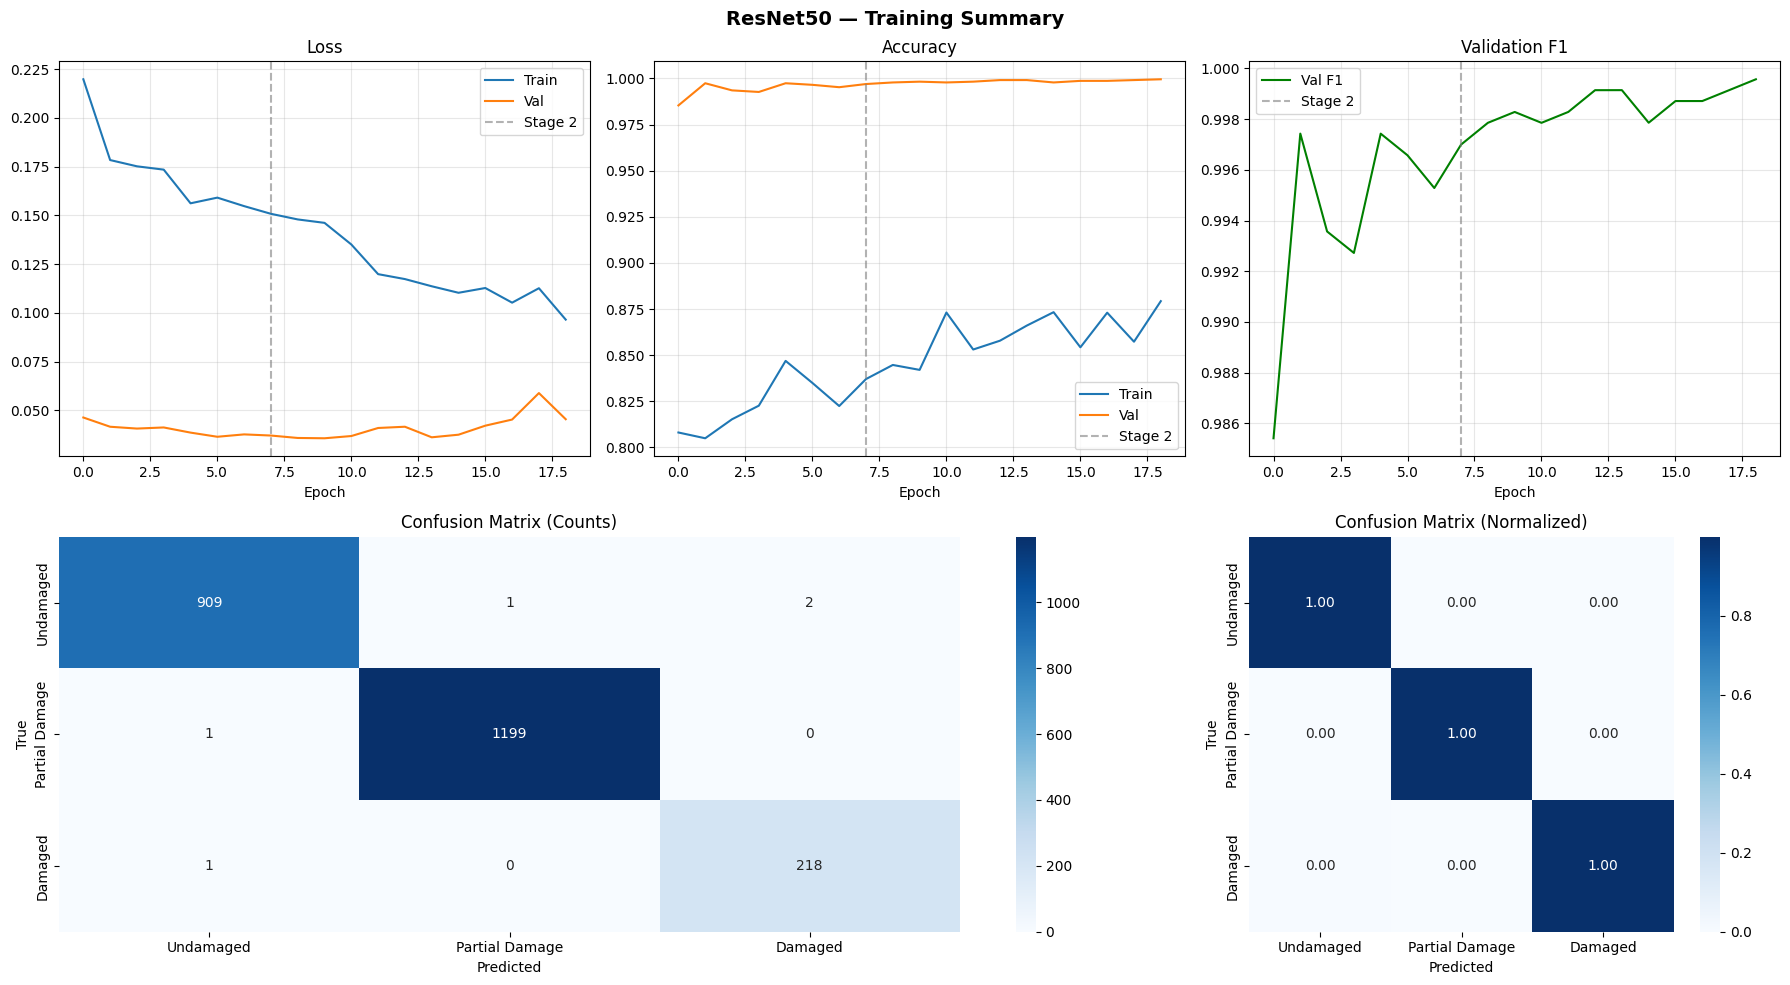

Saved to /content/drive/MyDrive/heritage_damage_assessment/outputs/training_summary.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import json

# Load best weights into model with EMA
best_ckpt = load_checkpoint("resnet50_best.pth")
model.load_state_dict(best_ckpt["model_state"])
ema.load_state_dict(best_ckpt["ema_state"])
print(f"Loaded best checkpoint — epoch {best_ckpt['epoch']+1}, val F1 {best_ckpt['best_f1']:.4f}\n")

# Test evaluation using EMA weights
_, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, CONFIG)
test_f1 = f1_score(test_labels, test_preds, average="weighted")

print("Test set results:")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 (weighted) : {test_f1:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=CONFIG["class_names"]))

history = best_ckpt["history"]

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)
fig.suptitle("ResNet50 — Training Summary", fontsize=14, fontweight="bold")

# Loss curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.axvline(CONFIG["stage1_epochs"] - 1, color="gray", linestyle="--", alpha=0.6, label="Stage 2")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.axvline(CONFIG["stage1_epochs"] - 1, color="gray", linestyle="--", alpha=0.6, label="Stage 2")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1 curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(history["val_f1"], color="green", label="Val F1")
ax3.axvline(CONFIG["stage1_epochs"] - 1, color="gray", linestyle="--", alpha=0.6, label="Stage 2")
ax3.set_title("Validation F1")
ax3.set_xlabel("Epoch")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Confusion matrix — counts
ax4 = fig.add_subplot(gs[1, 0:2])
cm  = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax4,
            xticklabels=CONFIG["class_names"],
            yticklabels=CONFIG["class_names"])
ax4.set_title("Confusion Matrix (Counts)")
ax4.set_ylabel("True")
ax4.set_xlabel("Predicted")

# Confusion matrix — normalized
ax5 = fig.add_subplot(gs[1, 2])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax5,
            xticklabels=CONFIG["class_names"],
            yticklabels=CONFIG["class_names"])
ax5.set_title("Confusion Matrix (Normalized)")
ax5.set_ylabel("True")
ax5.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(f"{DIRS['outputs']}/training_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved to {DIRS['outputs']}/training_summary.png")